✅ Data Loaded Successfully!
   Year  GDP Growth (%)  SENSEX  Inflation (%)  Exch Rate (INR/USD)  \
0  1980            3.37    0.00          11.35                 7.86   
1  1981            3.95  148.25          13.00                 8.66   
2  1982            3.73  214.56           7.20                 9.46   
3  1983            3.60  222.14           9.60                10.10   
4  1984            3.16  236.21           8.40                11.36   

   SENSEX_Ret (%)  Mod_Infl_Dummy (4-6%)  High_Infl_Dummy (>6%)  
0             NaN                      0                      1  
1           48.25                      0                      1  
2           44.73                      0                      1  
3            3.53                      0                      1  
4            6.33                      0                      1  

🧹 Missing Values:
 Year                     0
GDP Growth (%)           0
SENSEX                   0
Inflation (%)            0
Exch Rate (INR/USD)  

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


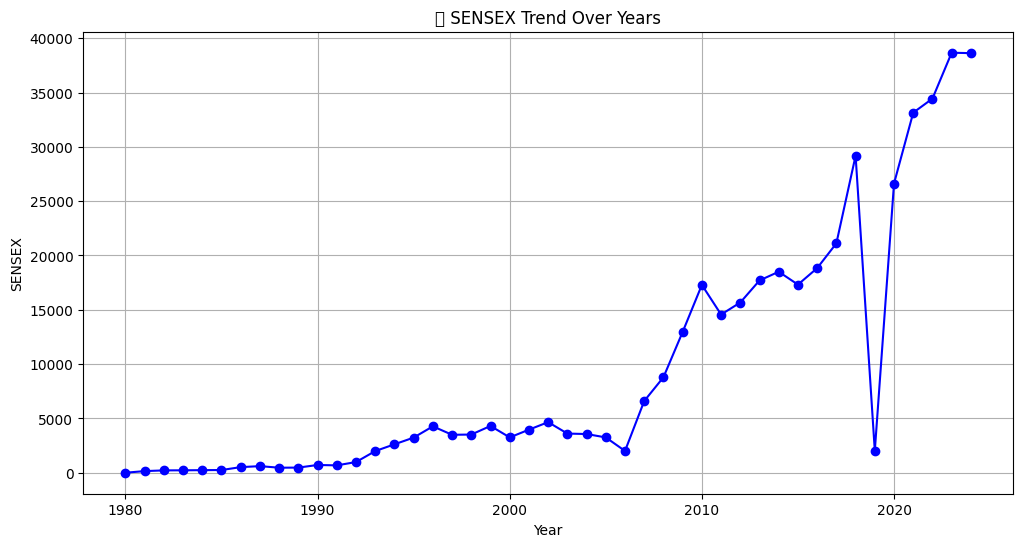

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


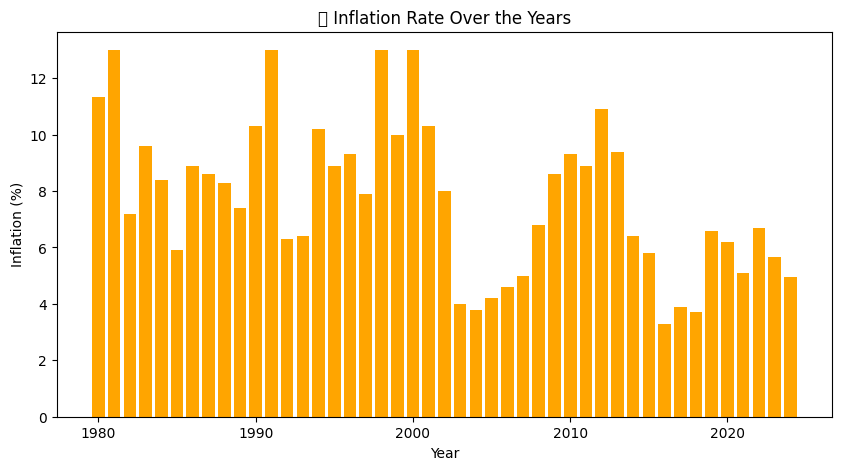

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


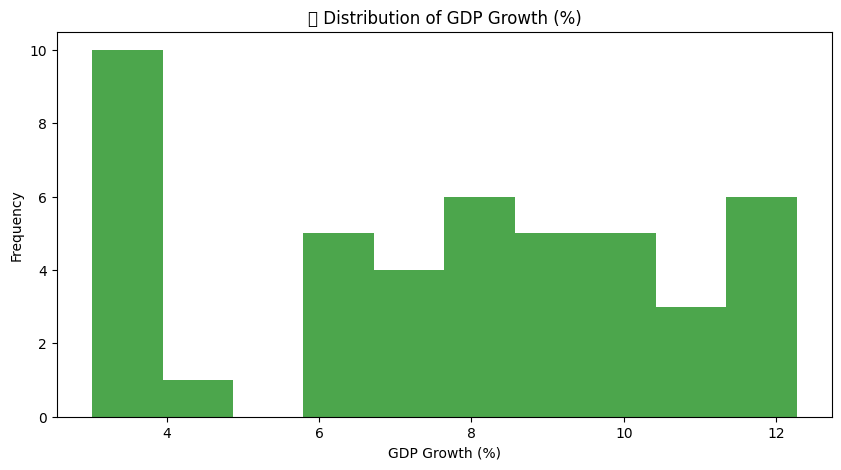

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128185 (\N{CHART WITH UPWARDS TREND AND YEN SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


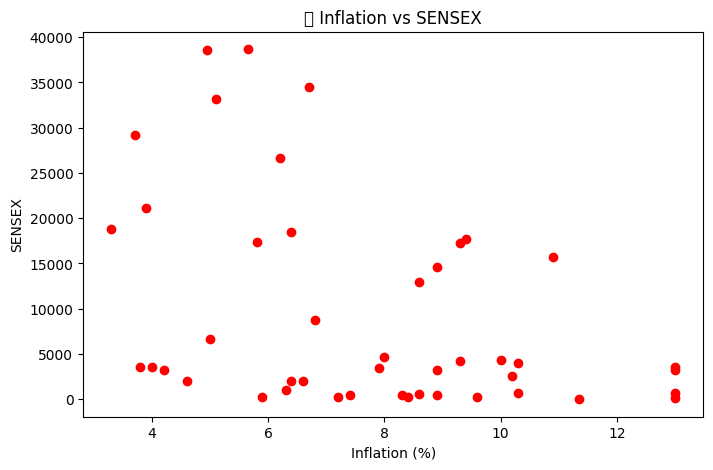

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


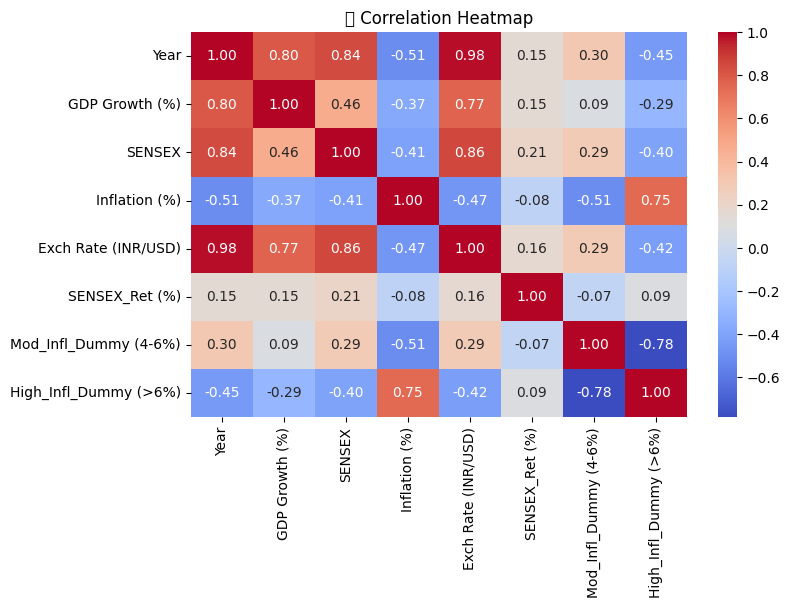

In [ ]:
# 📊 EDA on Indian Stock Market & Economic Data (Excel Version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# -------------------------------
# 1️⃣ Load the Dataset (.xlsx)
# -------------------------------
# Replace with your actual Excel filename
df = pd.read_excel("India_Stock_Market_Data.xlsx")

print("✅ Data Loaded Successfully!")
print(df.head())

# -------------------------------
# 2️⃣ Data Cleaning
# -------------------------------

# a. Check missing values
print("\n🧹 Missing Values:\n", df.isnull().sum())

# Fill missing numeric values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# b. Remove duplicates
duplicates = df.duplicated().sum()
print(f"\n🗑️ Duplicates Found: {duplicates}")
df.drop_duplicates(inplace=True)

# c. Ensure correct data types
df['Year'] = df['Year'].astype(int)

# d. Clean column names
df.columns = df.columns.str.strip()

# -------------------------------
# 3️⃣ Data Normalization
# -------------------------------
scaler = MinMaxScaler()
scaled_cols = ['GDP Growth (%)', 'SENSEX', 'Inflation (%)', 'Exch Rate (INR/USD)']
df_scaled = df.copy()
df_scaled[scaled_cols] = scaler.fit_transform(df_scaled[scaled_cols])

print("\n🔄 Data Normalized (Min-Max Scaling Applied)")

# -------------------------------
# 4️⃣ Data Inspection & Analysis
# -------------------------------

print("\n🔍 Dataset Info:")
print(df.info())

print("\n📈 Descriptive Statistics:")
print(df.describe())

# Filter: High Inflation Years (>6%)
high_infl = df[df['Inflation (%)'] > 6]
print(f"\n🔥 Years with Inflation > 6%:\n{high_infl[['Year', 'Inflation (%)']]}")

# Example Stats: SENSEX
mean_sensex = df['SENSEX'].mean()
median_sensex = df['SENSEX'].median()
mode_sensex = df['SENSEX'].mode()[0]
range_sensex = df['SENSEX'].max() - df['SENSEX'].min()
variance_sensex = df['SENSEX'].var()
std_sensex = df['SENSEX'].std()

print(f"""
📊 SENSEX Summary:
Mean: {mean_sensex:.2f}
Median: {median_sensex:.2f}
Mode: {mode_sensex:.2f}
Range: {range_sensex:.2f}
Variance: {variance_sensex:.2f}
Std Dev: {std_sensex:.2f}
""")

# -------------------------------
# 5️⃣ Data Visualization
# -------------------------------

# Line Plot
plt.figure(figsize=(12, 6))
plt.plot(df['Year'], df['SENSEX'], marker='o', color='blue')
plt.title("📈 SENSEX Trend Over Years")
plt.xlabel("Year")
plt.ylabel("SENSEX")
plt.grid(True)
plt.show()

# Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(df['Year'], df['Inflation (%)'], color='orange')
plt.title("🔥 Inflation Rate Over the Years")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.show()

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df['GDP Growth (%)'], bins=10, color='green', alpha=0.7)
plt.title("📊 Distribution of GDP Growth (%)")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()

# Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Inflation (%)'], df['SENSEX'], color='red')
plt.title("💹 Inflation vs SENSEX")
plt.xlabel("Inflation (%)")
plt.ylabel("SENSEX")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📉 Correlation Heatmap")
plt.show()
